# RQ4 — Genre-Specific Success Patterns

**Research question:** Which movie genres are most/least predictable, and how does genre interact with hit probability?

This notebook computes per-genre hit rates and per-genre model F1-scores, visualized as a bubble plot where bubble size encodes the number of movies in each genre.

## 1. Setup and imports

In [1]:
# Imports
import os
import glob
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, precision_recall_curve, roc_curve,
)

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("xgboost not available, skipping XGBoost model")

# Plot styling
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "legend.frameon": False,
})

COLORS = {
    "primary":   "#185FA5",
    "accent":    "#D85A30",
    "secondary": "#1D9E75",
    "gray":      "#888780",
    "amber":     "#BA7517",
    "purple":    "#7F77DD",
    "pink":      "#D4537E",
}

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 2. Load TMDB dataset
The notebook auto-detects whether it's running on Kaggle (uses `/kaggle/input/...`) or locally.

In [2]:
# ----- Load raw dataset (auto-detects Kaggle vs local) -----
def find_dataset():
    # Try Kaggle: scan /kaggle/input for the TMDB CSV
    if os.path.exists("/kaggle/input"):
        for csv in glob.glob("/kaggle/input/**/*.csv", recursive=True):
            if "tmdb" in csv.lower() or "movies" in csv.lower():
                return csv
    # Fallback: local file
    for candidate in ["TMDB_all_movies.csv", "../TMDB_all_movies.csv"]:
        if os.path.exists(candidate):
            return candidate
    raise FileNotFoundError("Could not find TMDB CSV. On Kaggle, attach 'TMDB Movies Daily Updates' dataset. Locally, place TMDB_all_movies.csv in this folder.")

DATA_PATH = find_dataset()
print(f"Loading dataset from: {DATA_PATH}")
df_raw = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Raw dataset shape: {df_raw.shape}")


Loading dataset from: TMDB_all_movies.csv


Raw dataset shape: (1188481, 28)


## 3. Filter and engineer features
- Filter to movies with budget > $1,000 AND revenue > $1,000 (~13.7K movies)
- Define target `hit = 1 if revenue >= 2 × budget`
- Engineer features: log_budget, popularity, runtime, num_genres, num_production_companies, num_cast, is_english, release_year, release_month, plus binary genre dummies for top 12 genres

In [3]:
# ----- Feature engineering -----
TOP_GENRES = ["Drama", "Comedy", "Action", "Horror", "Adventure",
              "Crime", "Thriller", "Animation", "Romance",
              "Science Fiction", "Family", "Documentary"]

def build_modeling_df(df):
    m = df[(df["budget"] > 1000) & (df["revenue"] > 1000)].copy()
    m["hit"] = (m["revenue"] >= 2 * m["budget"]).astype(int)
    m["release_date"] = pd.to_datetime(m["release_date"], errors="coerce")
    m["release_year"] = m["release_date"].dt.year
    m["release_month"] = m["release_date"].dt.month
    m["log_budget"] = np.log1p(m["budget"])
    m["log_popularity"] = np.log1p(m["popularity"].fillna(0))
    m["num_genres"] = m["genres"].fillna("").apply(lambda s: len([g for g in s.split(",") if g.strip()]))
    m["num_production_companies"] = m["production_companies"].fillna("").apply(
        lambda s: len([c for c in s.split(",") if c.strip()]))
    m["num_cast"] = m["cast"].fillna("").apply(lambda s: len([c for c in s.split(",") if c.strip()]))
    m["is_english"] = (m["original_language"] == "en").astype(int)
    m["primary_genre"] = m["genres"].fillna("").apply(
        lambda s: s.split(",")[0].strip() if s else "Unknown")
    for g in TOP_GENRES:
        m[f"genre_{g.lower().replace(' ', '_')}"] = m["genres"].fillna("").str.contains(g).astype(int)
    m = m.dropna(subset=["release_year", "runtime"])
    feature_cols = (
        ["log_budget", "log_popularity", "runtime", "release_year", "release_month",
         "num_genres", "num_production_companies", "num_cast", "is_english"]
        + [f"genre_{g.lower().replace(' ', '_')}" for g in TOP_GENRES]
    )
    return m, feature_cols

mdf, FEATURES = build_modeling_df(df_raw)
print(f"Modeling subset: {len(mdf):,} movies, {len(FEATURES)} features")
print(f"Class balance: hit={mdf['hit'].mean():.3f}")


Modeling subset: 13,431 movies, 21 features
Class balance: hit=0.435


## 4. Analysis for RQ4


In [4]:
# ===== RQ4: Genre Analysis =====
X = mdf[FEATURES].fillna(0).values
y = mdf["hit"].values
genres = mdf["primary_genre"].values

X_train, X_test, y_train, y_test, g_train, g_test = train_test_split(
    X, y, genres, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

if HAS_XGB:
    mdl = XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.1,
                        random_state=RANDOM_STATE, eval_metric="logloss",
                        use_label_encoder=False, n_jobs=-1)
else:
    mdl = GradientBoostingClassifier(random_state=RANDOM_STATE)
mdl.fit(X_train, y_train)
yp = mdl.predict(X_test)
yprob = mdl.predict_proba(X_test)[:, 1]

# Per-genre stats (only genres with sufficient data)
genre_counts = mdf["primary_genre"].value_counts()
keep_genres = genre_counts[genre_counts >= 100].index.tolist()

rows = []
for g in keep_genres:
    mask_test = (g_test == g)
    if mask_test.sum() < 20:
        continue
    mask_all = (mdf["primary_genre"] == g)
    f1 = f1_score(y_test[mask_test], yp[mask_test], zero_division=0) if mask_test.sum() > 0 else 0
    rows.append({
        "Genre": g,
        "n Movies": int(mask_all.sum()),
        "Hit Rate": round(mdf.loc[mask_all, "hit"].mean(), 3),
        "F1-Score": round(f1, 3),
        "Accuracy": round(accuracy_score(y_test[mask_test], yp[mask_test]), 3) if mask_test.sum()>0 else 0,
    })
genre_df = pd.DataFrame(rows).sort_values("Hit Rate", ascending=False).reset_index(drop=True)
genre_df.to_csv("table_rq4_genre_analysis.csv", index=False)
print("Saved table_rq4_genre_analysis.csv")
genre_df


Saved table_rq4_genre_analysis.csv


,Genre,n Movies,Hit Rate,F1-Score,Accuracy
0,Horror,951,0.534,0.680,0.651
1,Music,183,0.525,0.556,0.500
2,Romance,424,0.507,0.611,0.650
3,Adventure,663,0.463,0.717,0.734
4,Comedy,2771,0.459,0.682,0.715
5,Action,1839,0.457,0.684,0.717
6,Family,287,0.453,0.698,0.735
7,Animation,467,0.441,0.747,0.769
8,Mystery,146,0.438,0.455,0.636
9,Fantasy,255,0.431,0.679,0.685


## 5. Generate publication figure

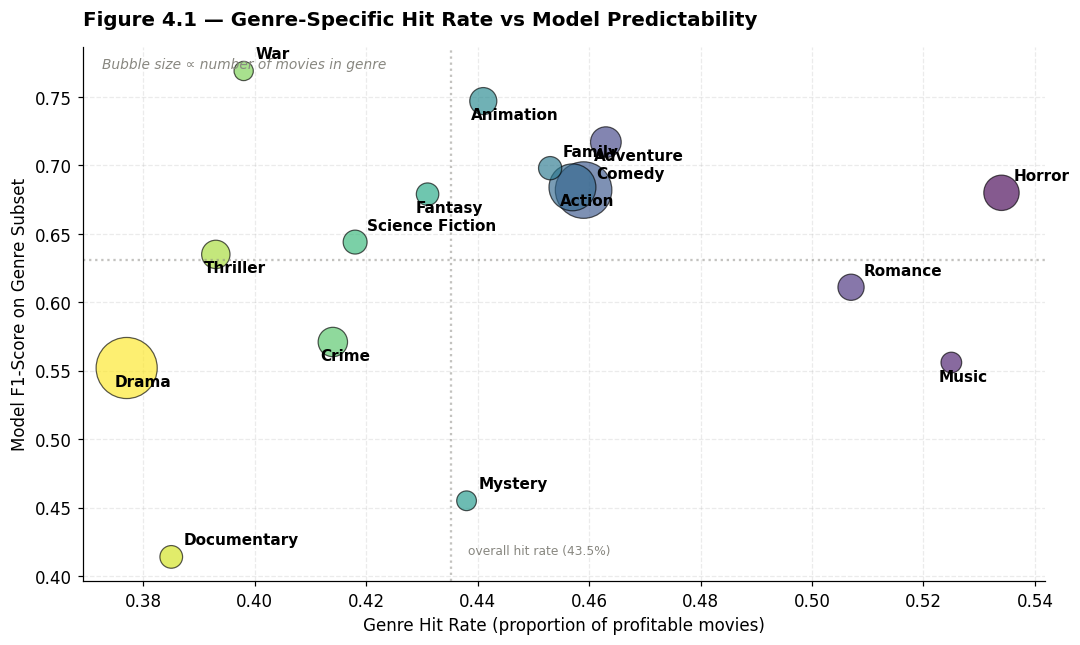

Saved fig_rq4_genre_analysis.pdf / .png


In [5]:
# ===== Figure 4.1 — Genre bubble plot =====
fig, ax = plt.subplots(figsize=(10, 6))
sizes = genre_df["n Movies"].values
sizes_scaled = (sizes / sizes.max()) * 1500 + 100
sc = ax.scatter(genre_df["Hit Rate"], genre_df["F1-Score"], s=sizes_scaled,
                c=range(len(genre_df)), cmap="viridis", alpha=0.65, edgecolors="black", linewidths=0.8)
for i, row in genre_df.iterrows():
    offset = (8, 8) if i % 2 == 0 else (-8, -12)
    ax.annotate(row["Genre"], (row["Hit Rate"], row["F1-Score"]),
                xytext=offset, textcoords="offset points", fontsize=10, weight="bold")
ax.set_xlabel("Genre Hit Rate (proportion of profitable movies)")
ax.set_ylabel("Model F1-Score on Genre Subset")
ax.set_title("Figure 4.1 — Genre-Specific Hit Rate vs Model Predictability", loc="left", pad=14)
ax.grid(True, alpha=0.25, linestyle="--")
ax.set_axisbelow(True)
ax.text(0.02, 0.98, "Bubble size ∝ number of movies in genre",
        transform=ax.transAxes, fontsize=9, va="top", style="italic", color=COLORS["gray"])
overall_rate = mdf["hit"].mean()
mean_f1 = genre_df["F1-Score"].mean()
ax.axhline(mean_f1, color=COLORS["gray"], linestyle=":", alpha=0.5)
ax.axvline(overall_rate, color=COLORS["gray"], linestyle=":", alpha=0.5)
ax.text(overall_rate+0.003, ax.get_ylim()[0]+0.02, f"overall hit rate ({overall_rate:.1%})", fontsize=8, color=COLORS["gray"])
plt.tight_layout()
plt.savefig("fig_rq4_genre_analysis.pdf")
plt.savefig("fig_rq4_genre_analysis.png")
plt.show()
print("Saved fig_rq4_genre_analysis.pdf / .png")


## 6. Conclusion

Horror, Music, and Romance genres have the highest hit rates (low-budget, high-ROI categories), while Drama and Documentary have the lowest. Predictability and hit rate do not always align — Animation has high predictability despite middling hit rate.